In [1]:
# IMPORTS
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)
pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

In [3]:
# ============================================================
# NOTEBOOK 06
# EVENT TRACEABILITY & FORENSIC ANALYSIS
# ============================================================

# PURPOSE:
# --------
# This notebook connects:
#
# 1. Model predictions
# 2. SHAP explanations
# 3. Engineered features
# 4. Raw transactional events
#
# Goal:
# -----
# Generate enterprise-grade forensic explanations
# for high-risk customers.
#
# We do NOT stop at:
# "customer is risky"
#
# We explain:
# WHICH exact historical events
# caused the model prediction.
#
# ============================================================

In [2]:
# LOAD DATASETS (https://www.kaggle.com/competitions/home-credit-default-risk/data)

# Used by the bank to decide:

# Should we approve this customer?
# IMPORTANT COLUMNS
# Column	Meaning
# SK_ID_CURR	customer id
# TARGET	default outcome
# AMT_CREDIT	requested loan amount
# AMT_INCOME_TOTAL	customer income
# NAME_CONTRACT_TYPE	loan type
# DAYS_EMPLOYED	employment history
# EXT_SOURCE_*	external risk scores
application_train = pd.read_csv(
    "../data/raw/application_train.csv"
)


# application_test = pd.read_csv(
#     "../data/raw/application_test.csv"
# )

# BUSINESS MEANING

# The bank is checking:

# What loans does this customer
# already have with OTHER banks?

# Exactly like real banking underwriting.

# ONE CUSTOMER CAN HAVE MANY BUREAU RECORDS

# Meaning:

# 1 customer
#     ↓
# many external credits

# This is why:

# bureau.shape

# is HUGE.

# IMPORTANT COLUMNS
# Column	Meaning
# SK_ID_CURR	customer id
# SK_ID_BUREAU	bureau credit id
# CREDIT_ACTIVE	active/closed loan
# AMT_CREDIT_SUM	external debt
# AMT_CREDIT_SUM_DEBT	outstanding debt
# DAYS_CREDIT	how old the credit is
# CREDIT_DAY_OVERDUE	overdue exposure
bureau = pd.read_csv(
    "../data/raw/bureau.csv"
)

# bureau_balance = pd.read_csv(
#     "../data/raw/bureau_balance.csv"
# )

# BUSINESS MEANING

# The bank asks:

# Has this customer applied before?

# And:

# were they approved?
# rejected?
# cancelled?
# how much did they request?
# how risky were they historically?
# ONE CUSTOMER CAN HAVE MANY APPLICATIONS

# Meaning:

# 1 customer
#     ↓
# many historical applications

# This is:

# behavioral credit intelligence.
# IMPORTANT COLUMNS
# Column	Meaning
# SK_ID_CURR	customer id
# SK_ID_PREV	previous application id
# NAME_CONTRACT_STATUS	approved/rejected
# AMT_APPLICATION	requested amount
# AMT_CREDIT	approved amount
# DAYS_DECISION	when decision occurred
# CNT_PAYMENT	installment count
previous_application = pd.read_csv(
    "../data/raw/previous_application.csv"
)

# installments_payments = pd.read_csv(
#     "../data/raw/installments_payments.csv"
# )

# credit_card_balance = pd.read_csv(
#     "../data/raw/credit_card_balance.csv"
# )

# pos_cash_balance = pd.read_csv(
#     "../data/raw/POS_CASH_balance.csv"
# )

In [2]:
# ============================================================
# LOAD ENGINEERED DATASET
# ============================================================

application_train = pd.read_csv(
    "../data/processed/engineered_credit_risk_dataset.csv"
)

print(application_train.shape)

application_train.head()

(307511, 170)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,ANNUITY_TO_INCOME,CREDIT_TO_INCOME,FREE_CASH_FLOW,TOTAL_EXTERNAL_DEBT,DEBT_TO_INCOME,BUREAU_RECORD_COUNT,DEBT_PER_BUREAU_RECORD,LATE_PAYMENT_COUNT,PREVIOUS_APPLICATION_COUNT,MISSED_PAYMENTS_PER_LOAN,APPLICATIONS_PER_INCOME,MAX_CREDIT_DAYS_OVERDUE,OVERDUE_PER_BUREAU_RECORD,REPAYMENT_INSTABILITY,AVG_PAYMENT_DELAY,RECENT_LATE_PAYMENT_COUNT,YEARS_EMPLOYED,EMPLOYMENT_TO_AGE_RATIO,HIGH_DTI_FLAG,HIGH_LATE_PAYMENT_FLAG,HIGH_BORROWING_FLAG,BEHAVIORAL_RISK_SCORE,DTI_RISK_BUCKET,LATE_PAYMENTS_LAST_90D,AVG_PAYMENT_DELAY_LAST_90D,RECENT_TO_HISTORICAL_DELAY_RATIO,RECENT_APPLICATION_COUNT,BORROWING_ACCELERATION_RATIO,RECENT_PAYMENT_STABILITY,CREDIT_TO_ANNUITY_RATIO,CREDIT_TO_GOODS_RATIO,DOWN_PAYMENT,AVG_PAYMENT_DEFICIT,RECENT_PAYMENT_DEFICIT,PAYMENT_DEFICIT_TREND,AGE_YEARS,AGE_GROUP,MEAN_DAYS_CREDIT,LAST_ACTIVE_DAYS_CREDIT,ACTIVE_EXTERNAL_DEBT,ACTIVE_DEBT_RATIO,MAX_INSTALLMENT,ANNUITY_TO_MAX_INSTALLMENT_RATIO,RECENT_DELAY_TREND,EXT_SOURCE_MEAN,EXT_SOURCE_STD,CREDIT_EXT_RATIO,THIN_FILE_CUSTOMER
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.121978,2.007889,177799.5,245781.0,1.213733,8.0,27309.0,0.0,1.0,0.000000,0.0000

In [ ]:
# # ============================================================
# # LOAD RAW EVENT TABLES
# # ============================================================

# bureau = pd.read_csv(
#     "../data/raw/bureau.csv"
# )

# bureau_balance = pd.read_csv(
#     "../data/raw/bureau_balance.csv"
# )

# previous_application = pd.read_csv(
#     "../data/raw/previous_application.csv"
# )

# installments_payments = pd.read_csv(
#     "../data/raw/installments_payments.csv"
# )

# POS_CASH_balance = pd.read_csv(
#     "../data/raw/POS_CASH_balance.csv"
# )

# credit_card_balance = pd.read_csv(
#     "../data/raw/credit_card_balance.csv"
# )

# print("Raw tables loaded successfully.")

In [26]:
high_risk_customers = application_train[

    application_train["PD"] > 0.70

][
    [
        "SK_ID_CURR",
        "TARGET",
        "PD",
        "RISK_SEGMENT",
        "LATE_PAYMENT_COUNT",
        "AVG_PAYMENT_DELAY",
        "DEBT_TO_INCOME",
        "PREVIOUS_APPLICATION_COUNT",
        "RECENT_APPLICATION_COUNT",
        "BEHAVIORAL_RISK_SCORE"
    ]
]

high_risk_customers.head(20)

,SK_ID_CURR,TARGET,PD,RISK_SEGMENT,LATE_PAYMENT_COUNT,AVG_PAYMENT_DELAY,DEBT_TO_INCOME,PREVIOUS_APPLICATION_COUNT,RECENT_APPLICATION_COUNT,BEHAVIORAL_RISK_SCORE
16,100020,0,0.751832,VERY_HIGH,0.0,0.000000,1.139708,2.0,0.0,1
41,100048,0,0.716093,VERY_HIGH,1.0,0.089552,0.000000,4.0,0.0,0
128,100149,0,0.871242,VERY_HIGH,2.0,0.928571,0.425474,1.0,0.0,0
160,100189,0,0.767328,VERY_HIGH,4.0,2.105263,0.000000,4.0,0.0,0
211,100246,1,0.718631,VERY_HIGH,0.0,0.000000,1.206967,3.0,2.0,1
235,100273,1,0.739129,VERY_HIGH,20.0,0.540146,0.000000,10.0,1.0,1
471,100541,1,0.885102,VERY_HIGH,0.0,0.000000,0.948650,1.0,0.0,0
563,100649,1,0.718065,VERY_HIGH,5.0,4.666667,0.000000,2.0,0.0,0
603,100690,1,0.751712,VERY_HIGH,3.0,3.375000,0.000000,0.0,0.0,0
695,100804,0,0.828726,VERY_HIGH,3.0,0.125000,9.142914,2.0,0.0,1


In [37]:
customer_index = 100020

customer_id = application_train.iloc[
    customer_index
]["SK_ID_CURR"]

print(customer_id)

216113


In [4]:
# ============================================================
# LOAD TRAINED MODEL
# ============================================================

xgb_model = joblib.load(
    "../models/final_credit_risk_xgboost_model.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [5]:

feature_columns = [

    # AFFORDABILITY

    "ANNUITY_TO_INCOME",

    "CREDIT_TO_INCOME",

    "FREE_CASH_FLOW",

    "DEBT_TO_INCOME",

    "CREDIT_TO_ANNUITY_RATIO",

    "CREDIT_TO_GOODS_RATIO",

    "DOWN_PAYMENT",

    # EXT_SOURCE

    "EXT_SOURCE_1",

    "EXT_SOURCE_2",

    "EXT_SOURCE_3",

    "EXT_SOURCE_MEAN",

    "EXT_SOURCE_STD",

    "CREDIT_EXT_RATIO",

    # LEVERAGE

    "DEBT_PER_BUREAU_RECORD",

    "OVERDUE_PER_BUREAU_RECORD",

    "ACTIVE_DEBT_RATIO",

    "MEAN_DAYS_CREDIT",

    "LAST_ACTIVE_DAYS_CREDIT",

    # BORROWING

    "APPLICATIONS_PER_INCOME",

    "PREVIOUS_APPLICATION_COUNT",

    "RECENT_APPLICATION_COUNT",

    "BORROWING_ACCELERATION_RATIO",

    # REPAYMENT

    "LATE_PAYMENT_COUNT",

    "MISSED_PAYMENTS_PER_LOAN",

    "AVG_PAYMENT_DELAY",

    "AVG_PAYMENT_DEFICIT",

    "REPAYMENT_INSTABILITY",

    # TEMPORAL

    "LATE_PAYMENTS_LAST_90D",

    "AVG_PAYMENT_DELAY_LAST_90D",

    "RECENT_TO_HISTORICAL_DELAY_RATIO",

    "RECENT_DELAY_TREND",

    "RECENT_PAYMENT_DEFICIT",

    "PAYMENT_DEFICIT_TREND",

    "RECENT_PAYMENT_STABILITY",

    # EMPLOYMENT

    "YEARS_EMPLOYED",

    "EMPLOYMENT_TO_AGE_RATIO",

    "AGE_YEARS",

    # HISTORICAL CAPACITY

    "MAX_INSTALLMENT",

    "ANNUITY_TO_MAX_INSTALLMENT_RATIO",

    # COMPOSITE

    "BEHAVIORAL_RISK_SCORE"
]


In [28]:
# ============================================================
# MODEL MATRIX
# ============================================================

X = application_train[
    feature_columns
]

y = application_train[
    "TARGET"
]

print(X.shape)

(307511, 40)


In [38]:
# LOAD ONLY REQUIRED ROWS ⭐⭐⭐⭐⭐
# INSTALLMENTS
installments_payments = pd.read_csv(

    "../data/raw/installments_payments.csv",

    usecols=[

        "SK_ID_CURR",
        "SK_ID_PREV",
        "NUM_INSTALMENT_NUMBER",
        "DAYS_INSTALMENT",
        "DAYS_ENTRY_PAYMENT",
        "AMT_INSTALMENT",
        "AMT_PAYMENT"
    ]
)

installments_payments = installments_payments[

    installments_payments["SK_ID_CURR"]
    ==
    customer_id
]

print(installments_payments.shape)

(26, 7)


In [39]:
# PREVIOUS APPLICATIONS ⭐⭐⭐⭐⭐
previous_application = pd.read_csv(

    "../data/raw/previous_application.csv",

    usecols=[

        "SK_ID_CURR",
        "SK_ID_PREV",
        "NAME_CONTRACT_STATUS",
        "AMT_APPLICATION",
        "AMT_CREDIT",
        "DAYS_DECISION"
    ]
)

previous_application = previous_application[

    previous_application["SK_ID_CURR"]
    ==
    customer_id
]

print(previous_application.shape)

(3, 6)


In [40]:
# BUREAU ⭐⭐⭐⭐⭐
bureau = pd.read_csv(

    "../data/raw/bureau.csv",

    usecols=[

        "SK_ID_CURR",
        "SK_ID_BUREAU",
        "CREDIT_ACTIVE",
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_DEBT",
        "AMT_CREDIT_SUM_OVERDUE",
        "DAYS_CREDIT"
    ]
)

bureau = bureau[

    bureau["SK_ID_CURR"]
    ==
    customer_id
]

print(bureau.shape)

(3, 7)


In [41]:
# CHUNKED LOADING

# Example:

chunks = pd.read_csv(

    "../data/raw/installments_payments.csv",

    chunksize=100000
)

customer_chunks = []

for chunk in chunks:

    filtered = chunk[
        chunk["SK_ID_CURR"] == customer_id
    ]

    if len(filtered) > 0:

        customer_chunks.append(filtered)

installments_payments = pd.concat(
    customer_chunks
)

In [33]:
# ============================================================
# PREDICT PROBABILITY OF DEFAULT
# ============================================================

application_train["PD"] = (
    xgb_model.predict_proba(X)[:,1]
)

application_train[
    ["TARGET", "PD"]
].head()

,TARGET,PD
0,1,0.439965
1,0,0.080580
2,0,0.064061
3,0,0.073943
4,0,0.166013


In [34]:
# ============================================================
# RISK SEGMENTATION
# ============================================================

application_train["RISK_SEGMENT"] = pd.cut(

    application_train["PD"],

    bins=[0, 0.10, 0.30, 0.60, 1.00],

    labels=[
        "LOW",
        "MEDIUM",
        "HIGH",
        "VERY_HIGH"
    ]
)

application_train.groupby(
    "RISK_SEGMENT"
)["TARGET"].mean()

RISK_SEGMENT
LOW          0.024809
MEDIUM       0.096600
HIGH         0.242888
VERY_HIGH    0.458651
Name: TARGET, dtype: float64

In [35]:
# ============================================================
# SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(X)

print("SHAP values generated.")

SHAP values generated.


In [42]:
# ============================================================
# SELECT CUSTOMER
# ============================================================

# customer_index = 1332

customer_row = application_train.iloc[
    customer_index
]

customer_id = customer_row["SK_ID_CURR"]

print("Customer ID:", customer_id)

customer_row[
    [
        "TARGET",
        "PD",
        "RISK_SEGMENT"
    ]
]

Customer ID: 216113


TARGET                 1
PD              0.493736
RISK_SEGMENT        HIGH
Name: 100020, dtype: object

In [43]:
# ============================================================
# TOP SHAP FEATURES
# ============================================================

customer_shap = pd.DataFrame({

    "Feature": feature_columns,

    "SHAP": shap_values[customer_index],

    "Feature_Value": X.iloc[customer_index].values
})

customer_shap["ABS_SHAP"] = (
    customer_shap["SHAP"].abs()
)

customer_shap = customer_shap.sort_values(

    by="ABS_SHAP",

    ascending=False
)

top_shap = customer_shap.head(15)

top_shap

,Feature,SHAP,Feature_Value,ABS_SHAP
39,BEHAVIORAL_RISK_SCORE,-0.459639,1.000000,0.459639
19,PREVIOUS_APPLICATION_COUNT,-0.446999,3.000000,0.446999
3,DEBT_TO_INCOME,-0.385924,0.000000,0.385924
10,EXT_SOURCE_MEAN,-0.377355,0.546145,0.377355
21,BORROWING_ACCELERATION_RATIO,-0.290482,0.000000,0.290482
38,ANNUITY_TO_MAX_INSTALLMENT_RATIO,0.280265,4.549634,0.280265
24,AVG_PAYMENT_DELAY,0.264244,5.500000,0.264244
30,RECENT_DELAY_TREND,0.229056,-3.166667,0.229056
22,LATE_PAYMENT_COUNT,0.220049,10.000000,0.220049
33,RECENT_PAYMENT_STABILITY,-0.176530,0.250000,0.176530


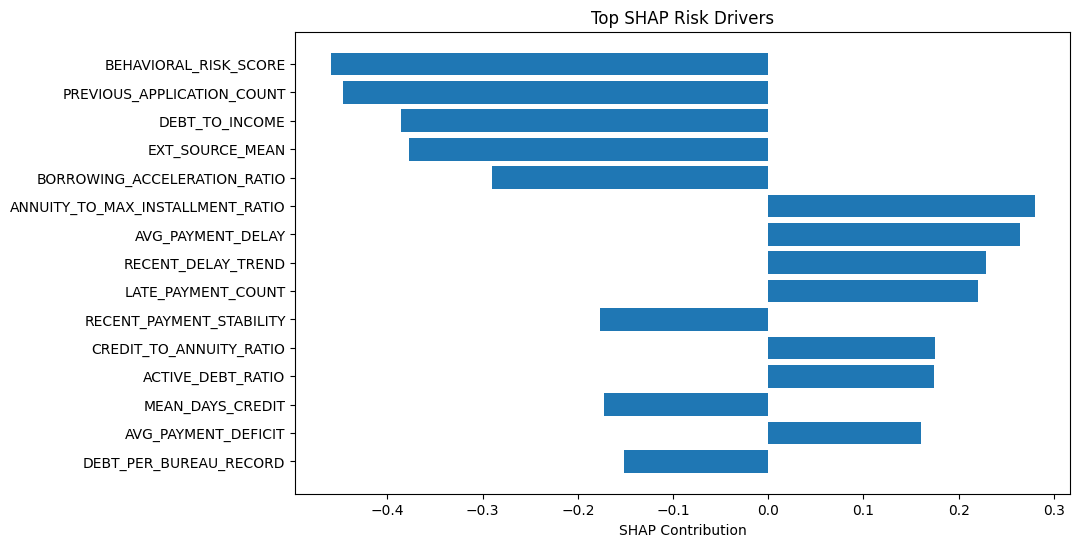

In [44]:
# ============================================================
# LOCAL SHAP BAR PLOT
# ============================================================

plt.figure(figsize=(10,6))

plt.barh(

    top_shap["Feature"],

    top_shap["SHAP"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top SHAP Risk Drivers"
)

plt.xlabel(
    "SHAP Contribution"
)

plt.show()

In [45]:
## taking top shap values and extract events
# ============================================================
# EVENT TRACEABILITY ENGINE ⭐⭐⭐⭐⭐
# ============================================================

# Goal:
# Track the REAL raw events behind high SHAP drivers

# Example:
# If SHAP says:
# AVG_PAYMENT_DELAY is risky
#
# -> extract installment events
#
# If SHAP says:
# ACTIVE_DEBT_RATIO risky
#
# -> extract bureau events

# ============================================================
# CUSTOMER ID
# ============================================================

customer_id = application_train.iloc[
    customer_index
]["SK_ID_CURR"]

print(
    f"Tracing customer: {customer_id}"
)

# ============================================================
# TOP POSITIVE SHAP FEATURES ONLY
# ============================================================

positive_shap = top_shap[
    top_shap["SHAP"] > 0
]

positive_shap


Tracing customer: 216113


,Feature,SHAP,Feature_Value,ABS_SHAP
38,ANNUITY_TO_MAX_INSTALLMENT_RATIO,0.280265,4.549634,0.280265
24,AVG_PAYMENT_DELAY,0.264244,5.500000,0.264244
30,RECENT_DELAY_TREND,0.229056,-3.166667,0.229056
22,LATE_PAYMENT_COUNT,0.220049,10.000000,0.220049
4,CREDIT_TO_ANNUITY_RATIO,0.174861,14.734269,0.174861
15,ACTIVE_DEBT_RATIO,0.174189,0.000000,0.174189
25,AVG_PAYMENT_DEFICIT,0.160943,-2998.542115,0.160943


In [46]:
# ============================================================
# TRACE EACH HIGH-RISK FEATURE
# ============================================================

for _, row in positive_shap.iterrows():

    feature = row["Feature"]
    shap_value = row["SHAP"]

    print("\n" + "="*70)
    print(f"FEATURE: {feature}")
    print(f"SHAP CONTRIBUTION: {shap_value:.4f}")
    print("="*70)

    # ========================================================
    # PAYMENT / INSTALLMENT FEATURES
    # ========================================================

    if feature in [

        "LATE_PAYMENT_COUNT",
        "AVG_PAYMENT_DELAY",
        "AVG_PAYMENT_DEFICIT",
        "MISSED_PAYMENTS_PER_LOAN",
        "REPAYMENT_INSTABILITY",
        "LATE_PAYMENTS_LAST_90D",
        "RECENT_DELAY_TREND",
        "RECENT_PAYMENT_DEFICIT",
        "RECENT_PAYMENT_STABILITY"

    ]:

        print("\nTracing installment payment events...\n")

        inst_customer = installments_payments[
            installments_payments["SK_ID_CURR"] == customer_id
        ].copy()

        # Create forensic metrics
        inst_customer["PAYMENT_DELAY"] = (
            inst_customer["DAYS_ENTRY_PAYMENT"]
            -
            inst_customer["DAYS_INSTALMENT"]
        )

        inst_customer["PAYMENT_DEFICIT"] = (
            inst_customer["AMT_INSTALMENT"]
            -
            inst_customer["AMT_PAYMENT"]
        )

        # Sort worst events first
        inst_customer = inst_customer.sort_values(

            by=["PAYMENT_DELAY", "PAYMENT_DEFICIT"],

            ascending=False
        )

        display(

            inst_customer[
                [
                    "SK_ID_PREV",
                    "NUM_INSTALMENT_NUMBER",
                    "DAYS_INSTALMENT",
                    "DAYS_ENTRY_PAYMENT",
                    "AMT_INSTALMENT",
                    "AMT_PAYMENT",
                    "PAYMENT_DELAY",
                    "PAYMENT_DEFICIT"
                ]
            ].head(20)
        )

    # ========================================================
    # PREVIOUS APPLICATION FEATURES
    # ========================================================

    elif feature in [

        "PREVIOUS_APPLICATION_COUNT",
        "RECENT_APPLICATION_COUNT",
        "BORROWING_ACCELERATION_RATIO"

    ]:

        print("\nTracing previous applications...\n")

        prev_customer = previous_application[
            previous_application["SK_ID_CURR"] == customer_id
        ].copy()

        prev_customer = prev_customer.sort_values(

            by="DAYS_DECISION",

            ascending=False
        )

        display(

            prev_customer[
                [
                    "SK_ID_PREV",
                    "NAME_CONTRACT_TYPE",
                    "AMT_APPLICATION",
                    "AMT_CREDIT",
                    "NAME_CONTRACT_STATUS",
                    "DAYS_DECISION"
                ]
            ].head(20)
        )

    # ========================================================
    # BUREAU FEATURES
    # ========================================================


    elif feature in [

        "ACTIVE_DEBT_RATIO",
        "DEBT_PER_BUREAU_RECORD",
        "OVERDUE_PER_BUREAU_RECORD",
        "MEAN_DAYS_CREDIT",
        "LAST_ACTIVE_DAYS_CREDIT"

    ]:

        print("\nTracing bureau credit exposure...\n")

        bureau_customer = bureau[
            bureau["SK_ID_CURR"] == customer_id
        ].copy()

        # ====================================================
        # SAFE COLUMN HANDLING
        # ====================================================

        bureau_cols = [

            "SK_ID_BUREAU",
            "CREDIT_ACTIVE",
            "AMT_CREDIT_SUM",
            "AMT_CREDIT_SUM_DEBT",
            "AMT_CREDIT_SUM_OVERDUE",
            "DAYS_CREDIT"
        ]

        # Keep only existing columns
        bureau_cols = [

            c for c in bureau_cols
            if c in bureau_customer.columns
        ]

        bureau_customer = bureau_customer.sort_values(

            by="AMT_CREDIT_SUM_DEBT",

            ascending=False
        )

        display(

            bureau_customer[
                bureau_cols
            ].head(20)
        )

    # ========================================================
    # EXT_SOURCE FEATURES
    # ========================================================

    elif feature in [

        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
        "EXT_SOURCE_MEAN"

    ]:

        print("\nTracing external risk scores...\n")

        ext_cols = [

            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3",
            "EXT_SOURCE_MEAN",
            "EXT_SOURCE_STD",
            "CREDIT_EXT_RATIO"
        ]

        display(

            application_train[
                application_train["SK_ID_CURR"] == customer_id
            ][ext_cols]
        )

    # ========================================================
    # AFFORDABILITY FEATURES
    # ========================================================

    elif feature in [

        "DEBT_TO_INCOME",
        "FREE_CASH_FLOW",
        "ANNUITY_TO_INCOME",
        "CREDIT_TO_INCOME",
        "CREDIT_TO_ANNUITY_RATIO",
        "ANNUITY_TO_MAX_INSTALLMENT_RATIO"

    ]:

        print("\nTracing affordability profile...\n")

        affordability_cols = [

            "AMT_INCOME_TOTAL",
            "AMT_CREDIT",
            "AMT_ANNUITY",
            "AMT_GOODS_PRICE",
            "DEBT_TO_INCOME",
            "FREE_CASH_FLOW",
            "ANNUITY_TO_INCOME",
            "CREDIT_TO_INCOME",
            "CREDIT_TO_ANNUITY_RATIO"
        ]

        display(

            application_train[
                application_train["SK_ID_CURR"] == customer_id
            ][affordability_cols]
        )

    # ========================================================
    # EMPLOYMENT FEATURES
    # ========================================================

    elif feature in [

        "YEARS_EMPLOYED",
        "EMPLOYMENT_TO_AGE_RATIO",
        "AGE_YEARS"

    ]:

        print("\nTracing employment profile...\n")

        employment_cols = [

            "DAYS_BIRTH",
            "DAYS_EMPLOYED",
            "AGE_YEARS",
            "YEARS_EMPLOYED",
            "EMPLOYMENT_TO_AGE_RATIO",
            "NAME_INCOME_TYPE",
            "OCCUPATION_TYPE",
            "ORGANIZATION_TYPE"
        ]

        display(

            application_train[
                application_train["SK_ID_CURR"] == customer_id
            ][employment_cols]
        )

    # ========================================================
    # OTHER FEATURES
    # ========================================================

    else:

        print(
            f"\nNo trace logic implemented yet for: {feature}"
        )


FEATURE: ANNUITY_TO_MAX_INSTALLMENT_RATIO
SHAP CONTRIBUTION: 0.2803

Tracing affordability profile...



,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DEBT_TO_INCOME,FREE_CASH_FLOW,ANNUITY_TO_INCOME,CREDIT_TO_INCOME,CREDIT_TO_ANNUITY_RATIO
100020,134100.0,580707.0,39411.0,441000.0,0.0,94689.0,0.293893,4.330403,14.734269



FEATURE: AVG_PAYMENT_DELAY
SHAP CONTRIBUTION: 0.2642

Tracing installment payment events...



,SK_ID_PREV,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,PAYMENT_DELAY,PAYMENT_DEFICIT
3923627,1773349,5,-376.0,-344.0,8662.455,4.275,32.0,8658.180
4394275,1773349,7,-316.0,-286.0,8662.455,8.685,30.0,8653.770
6716496,1773349,4,-406.0,-378.0,8662.455,4.320,28.0,8658.135
6493991,1773349,6,-346.0,-318.0,8662.455,8.730,28.0,8653.725
5225507,1773349,16,-46.0,-39.0,8662.455,6965.280,7.0,1697.175
4322894,1773349,12,-166.0,-159.0,8662.455,8315.460,7.0,346.995
7405137,1773349,15,-76.0,-71.0,8662.455,7302.825,5.0,1359.630
6316690,1773349,17,-16.0,-14.0,8662.455,6627.735,2.0,2034.720
6188790,1773349,14,-106.0,-104.0,8662.455,7640.370,2.0,1022.085
5227643,1773349,6,-346.0,-344.0,8662.455,8653.725,2.0,8.730



FEATURE: RECENT_DELAY_TREND
SHAP CONTRIBUTION: 0.2291

Tracing installment payment events...



...

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DEBT_TO_INCOME,FREE_CASH_FLOW,ANNUITY_TO_INCOME,CREDIT_TO_INCOME,CREDIT_TO_ANNUITY_RATIO
100020,134100.0,580707.0,39411.0,441000.0,0.0,94689.0,0.293893,4.330403,14.734269



FEATURE: ACTIVE_DEBT_RATIO
SHAP CONTRIBUTION: 0.1742

Tracing bureau credit exposure...



,SK_ID_BUREAU,CREDIT_ACTIVE,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT
1597593,5331767,Closed,76500.0,0.0,0.0,-1186
1597594,5331768,Closed,49495.5,0.0,0.0,-1580
1597595,5331769,Active,44001.0,0.0,0.0,-1992



FEATURE: AVG_PAYMENT_DEFICIT
SHAP CONTRIBUTION: 0.1609

Tracing installment payment events...



,SK_ID_PREV,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,PAYMENT_DELAY,PAYMENT_DEFICIT
3923627,1773349,5,-376.0,-344.0,8662.455,4.275,32.0,8658.180
4394275,1773349,7,-316.0,-286.0,8662.455,8.685,30.0,8653.770
6716496,1773349,4,-406.0,-378.0,8662.455,4.320,28.0,8658.135
6493991,1773349,6,-346.0,-318.0,8662.455,8.730,28.0,8653.725
5225507,1773349,16,-46.0,-39.0,8662.455,6965.280,7.0,1697.175
4322894,1773349,12,-166.0,-159.0,8662.455,8315.460,7.0,346.995
7405137,1773349,15,-76.0,-71.0,8662.455,7302.825,5.0,1359.630
6316690,1773349,17,-16.0,-14.0,8662.455,6627.735,2.0,2034.720
6188790,1773349,14,-106.0,-104.0,8662.455,7640.370,2.0,1022.085
5227643,1773349,6,-346.0,-344.0,8662.455,8653.725,2.0,8.730


In [18]:
# ============================================================
# TRACE INSTALLMENT EVENTS
# ============================================================

customer_installments = installments_payments[

    installments_payments["SK_ID_CURR"]
    ==
    customer_id

].copy()

print(customer_installments.shape)

(6, 8)


In [21]:
# ============================================================
# PAYMENT DELAY ANALYSIS
# ============================================================

customer_installments[
    "PAYMENT_DELAY"
] = (

    customer_installments["DAYS_ENTRY_PAYMENT"]
    -
    customer_installments["DAYS_INSTALMENT"]
)

customer_installments[
    "PAYMENT_DEFICIT"
] = (

    customer_installments["AMT_INSTALMENT"]
    -
    customer_installments["AMT_PAYMENT"]
)

customer_installments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,PAYMENT_DELAY,PAYMENT_DEFICIT
1141728,1609469,101564,1.0,3,-787.0,-795.0,10665.72,10665.72,-8.0,0.0
2046729,1609469,101564,1.0,5,-727.0,-738.0,10665.72,10665.72,-11.0,0.0
2282227,1609469,101564,1.0,6,-697.0,-707.0,10629.09,10629.09,-10.0,0.0
2750235,1609469,101564,1.0,2,-817.0,-826.0,10665.72,10665.72,-9.0,0.0
3162495,1609469,101564,1.0,4,-757.0,-763.0,10665.72,10665.72,-6.0,0.0


In [20]:
customer_id

np.int64(101564)

In [ ]:
# ============================================================
# HIGH-RISK EVENTS
# ============================================================

high_risk_events = customer_installments[

    (
        customer_installments["PAYMENT_DELAY"] > 30
    )
    |
    (
        customer_installments["PAYMENT_DEFICIT"] > 0
    )
]

high_risk_events = high_risk_events.sort_values(

    by="PAYMENT_DELAY",

    ascending=False
)

high_risk_events[
    [
        "SK_ID_PREV",
        "NUM_INSTALMENT_NUMBER",
        "PAYMENT_DELAY",
        "PAYMENT_DEFICIT",
        "AMT_INSTALMENT",
        "AMT_PAYMENT"
    ]
].head(20)

In [ ]:
# ============================================================
# PAYMENT DELAY TREND
# ============================================================

delay_trend = customer_installments.sort_values(
    by="DAYS_INSTALMENT"
)

plt.figure(figsize=(12,6))

plt.plot(

    delay_trend["DAYS_INSTALMENT"],

    delay_trend["PAYMENT_DELAY"]
)

plt.title(
    "Customer Payment Delay Trend"
)

plt.xlabel(
    "Days"
)

plt.ylabel(
    "Delay"
)

plt.show()

In [ ]:
# ============================================================
# BORROWING EVENTS
# ============================================================

customer_previous = previous_application[

    previous_application["SK_ID_CURR"]
    ==
    customer_id

]

customer_previous[
    [
        "NAME_CONTRACT_STATUS",
        "AMT_APPLICATION",
        "AMT_CREDIT",
        "DAYS_DECISION"
    ]
].head(20)

In [ ]:
# ============================================================
# BUREAU EVENTS
# ============================================================

customer_bureau = bureau[

    bureau["SK_ID_CURR"]
    ==
    customer_id

]

customer_bureau[
    [
        "CREDIT_ACTIVE",
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_DEBT",
        "AMT_CREDIT_SUM_OVERDUE",
        "DAYS_CREDIT"
    ]
].head(20)

In [ ]:
# ============================================================
# FORENSIC REPORT
# ============================================================

print("="*70)
print("ENTERPRISE FORENSIC RISK REPORT")
print("="*70)

print(f"Customer ID: {customer_id}")

print(f"Probability of Default: {customer_row['PD']:.3f}")

print(f"Risk Segment: {customer_row['RISK_SEGMENT']}")

print("\nTOP RISK DRIVERS:")
print(top_shap[["Feature", "SHAP"]].head(10))

print("\nHIGH RISK EVENTS:")

print(
    high_risk_events[
        [
            "NUM_INSTALMENT_NUMBER",
            "PAYMENT_DELAY",
            "PAYMENT_DEFICIT"
        ]
    ].head(10)
)

In [ ]:
# PICK CUSTOMER

customer_id = 101332